Import Dependencies

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit_aer import AerSimulator

Create a Parameter

In [2]:
theta = Parameter("θ")
print(f"Parameter name: {theta.name}")
print(f"Parameter type: {type(theta)}")

Parameter name: θ
Parameter type: <class 'qiskit._accelerate.circuit.Parameter'>


Build a Parameterized Circuit

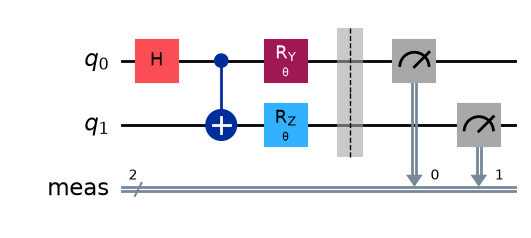

In [3]:
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.ry(theta, 0)
qc.rz(theta, 1)

qc.measure_all()
qc.draw("mpl")

Bind Values and Simulate

In [4]:
simulator = AerSimulator()

bound_circuit = qc.assign_parameters({theta: 1.57})

job = simulator.run(bound_circuit, shots=1024)
counts = job.result().get_counts()

print("Measurement counts:")
print(counts)

Measurement counts:
{'01': 263, '11': 246, '10': 257, '00': 258}


Working with ParameterVector

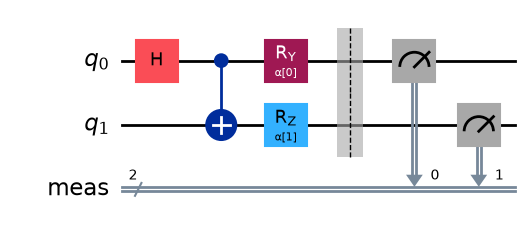

In [5]:
params = ParameterVector("α", length=2)

qc_vector = QuantumCircuit(2)
qc_vector.h(0)
qc_vector.cx(0, 1)
qc_vector.ry(params[0], 0)
qc_vector.rz(params[1], 1)
qc_vector.measure_all()

qc_vector.draw("mpl")

Bind Multiple Parameters

In [6]:
bound_vector = qc_vector.assign_parameters({params[0]: 0.78, params[1]: 2.35})

job = simulator.run(bound_vector, shots=1024)
counts = job.result().get_counts()

print("Measurement counts with multiple parameters:")
print(counts)

Measurement counts with multiple parameters:
{'01': 78, '10': 58, '00': 452, '11': 436}


Try Different Parameter Values

In [7]:
test_values = [0.0, 0.78, 1.57, 3.14]

for val in test_values:
    bound = qc.assign_parameters({theta: val})
    job = simulator.run(bound, shots=1024)
    counts = job.result().get_counts()
    print(f"θ = {val:.2f} → {counts}")

θ = 0.00 → {'11': 515, '00': 509}
θ = 0.78 → {'01': 73, '10': 65, '00': 456, '11': 430}
θ = 1.57 → {'11': 242, '01': 265, '10': 237, '00': 280}
θ = 3.14 → {'01': 545, '10': 479}
